<a href="https://colab.research.google.com/github/estheromoyiwola/Team-Energy-Load-Forecasting/blob/main/Copy_of_Team6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA COLLECTION, DATA WRANGLING, AND VISUALIZATION ASSIGNMENT
---

#PART A: Data Acquisition and Description

## 1. Dataset Source
The dataset used for this project is the ASHRAE Great Energy Predictor III dataset obtained from Kaggle. This dataset was developed for building energy prediction and contains building-level meter readings, weather information, and building metadata. It is appropriate for machine learning research in electricity forecasting because it combines time-series energy consumption records with environmental and structural building features.

Source platform: Kaggle
Dataset name: ASHRAE Great Energy Predictor III
URL:
```
https://www.kaggle.com/c/ashrae-energy-prediction || Access Date: March 28, 2026
```


## Data Extraction

This stage involve pulling data from the source data. Geting the data from the source , the data is splitted into 3 platform;
* **Train**: contains the main data with information such as `building_id`, `meter reading`, `meter number` and `timestamp`.
* **Weather_data** : information about weather of the location at different time.
* **Building_metadata**: information about the building usage, years of built and size is square feet.

I downloaded this data and saved in in my google drive

In [ ]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import matplotlib.dates as mdates


In [ ]:
# Mount the drive so that i can have access to the file i saved in the drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# read csv fromm the location you downloaded in your drive
base_path = "/content/drive/MyDrive/DS & ML Research Team_Spring_26/Esther New /ashrae_data/"
#/content/drive/MyDrive/DS & ML Research Team_Spring_26/Esther New /ashrae_data

# read the datasets
df_train = pd.read_csv(f"{base_path}/train.csv")
df_weather = pd.read_csv(f"{base_path}/weather_train.csv")
df_building_metadata = pd.read_csv(f"{base_path}/building_metadata.csv")

## 2. Dataset Description
The dataset is composed of three related CSV files:

train.csv

   - Contains the primary training observations
   - Includes building_id, meter, timestamp, and meter_reading
   - Target variable: meter_reading

weather_train.csv
   - Contains weather measurements for each site and timestamp
   - Includes variables such as air_temperature, cloud_coverage, dew_temperature, precipitation, sea_level_pressure, wind_direction, and wind_speed

building_metadata.csv
   - Contains static information about each building
   - Includes site_id, primary_use, square_feet, year_built, and floor_count

The target variable for this machine learning task is meter_reading, which represents the recorded energy consumption. The predictor variables are drawn from temporal information, weather conditions, and building characteristics after merging the three datasets.

In [ ]:

summary_df = pd.DataFrame({
    "Dataset": ["train.csv", "weather_train.csv", "building_metadata.csv"],
    "Rows": [df_train.shape[0], df_weather.shape[0], df_building_metadata.shape[0]],
    "Columns": [df_train.shape[1], df_weather.shape[1], df_building_metadata.shape[1]]
})

summary_df

,Dataset,Rows,Columns
0,train.csv,20216100,4
1,weather_train.csv,139773,9
2,building_metadata.csv,1449,6


## 3. Data Dictionary

The data dictionary below summarizes all variables used in the study, including their data types, meanings, and representative example values drawn from the dataset.

In [ ]:


def build_data_dictionary(df, descriptions, dataset_name):
    rows = []
    for col in df.columns:
        example_vals = df[col].dropna().unique()[:3]
        example_vals = ", ".join([str(v) for v in example_vals])
        rows.append({
            "Dataset": dataset_name,
            "Feature Name": col,
            "Data Type": str(df[col].dtype),
            "Description": descriptions.get(col, "Description not provided"),
            "Example Values": example_vals
        })
    return pd.DataFrame(rows)

train_desc = {
    "building_id": "Unique identifier for each building",
    "meter": "Meter type code where 0 = electricity, 1 = chilled water, 2 = steam, 3 = hot water",
    "timestamp": "Date and time when the meter reading was recorded",
    "meter_reading": "Measured energy consumption value; target variable"
}

weather_desc = {
    "site_id": "Unique identifier for each site",
    "timestamp": "Date and time of recorded weather observation",
    "air_temperature": "Air temperature in degrees Celsius",
    "cloud_coverage": "Portion of sky covered by clouds",
    "dew_temperature": "Dew point temperature in degrees Celsius",
    "precip_depth_1_hr": "Precipitation depth in the last 1 hour",
    "sea_level_pressure": "Atmospheric pressure at sea level",
    "wind_direction": "Wind direction in degrees from 0 to 360",
    "wind_speed": "Wind speed in meters per second"
}

building_desc = {
    "site_id": "Unique identifier for each site, used to join weather data",
    "building_id": "Unique identifier for each building, used to join training data",
    "primary_use": "Primary category of building activity",
    "square_feet": "Gross floor area of the building in square feet",
    "year_built": "Year the building was constructed",
    "floor_count": "Number of floors in the building"
}

dict_train = build_data_dictionary(df_train, train_desc, "train.csv")
dict_weather = build_data_dictionary(df_weather, weather_desc, "weather_train.csv")
dict_building = build_data_dictionary(df_building_metadata, building_desc, "building_metadata.csv")

data_dictionary_df = pd.concat([dict_train, dict_weather, dict_building], ignore_index=True)

data_dictionary_df

,Dataset,Feature Name,Data Type,Description,Example Values
0,train.csv,building_id,int64,Unique identifier for each building,"0, 1, 2"
1,train.csv,meter,int64,"Meter type code where 0 = electricity, 1 = chi...","0, 3, 1"
2,train.csv,timestamp,object,Date and time when the meter reading was recorded,"2016-01-01 00:00:00, 2016-01-01 01:00:00, 2016..."
3,train.csv,meter_reading,float64,Measured energy consumption value; target vari...,"0.0, 53.2397, 43.0013"
4,weather_train.csv,site_id,int64,Unique identifier for each site,"0, 1, 2"
5,weather_train.csv,timestamp,object,Date and time of recorded weather observation,"2016-01-01 00:00:00, 2016-01-01 01:00:00, 2016..."
6,weather_train.csv,air_temperature,float64,Air temperature in degrees Celsius,"25.0, 24.4, 22.8"
7,weather_train.csv,cloud_coverage,float64,Portion of sky covered by clouds,"6.0, 2.0, 4.0"
8,weather_train.csv,dew_temperature,float64,Dew point temperature in degrees Celsius,"20.0, 21.1, 20.6"
9,weather_train.csv,precip_depth_1_hr,float64,Precipitation depth in the last 1 hour,"-1.0, 0.0, 3.0"


## 4. Relevance Statement

This dataset directly supports the research topic of short-term electricity forecasting using machine learning with weather-integrated features. The ASHRAE dataset combines hourly meter readings with weather and building metadata, which makes it suitable for examining how factors such as temperature, wind speed, building size, and building use affect energy consumption patterns. In the literature review, many studies highlighted the value of combining temporal variables and weather information to improve forecasting accuracy. This dataset reflects those same conditions and therefore provides an appropriate real-world basis for model development. It also allows for the evaluation of multiple machine learning techniques, including ensemble methods, which are commonly discussed in recent forecasting studies. Another reason this dataset is appropriate is that it contains complex practical issues such as missing values, multiple building categories, and different usage behaviors, which makes the analysis more realistic and meaningful. Overall, the dataset is well aligned with the goal of building accurate and interpretable electricity forecasting models for data-driven energy management.

# PART B: Data Wrangling and Preprocessing

## Data Preprocessing
At this stage the following processs will be carried out
* preview the datasets.
* checks for discrepancies before the joins
* add the metadata to the train dataset using a join

In [ ]:
df_train.head(5) # preview the train

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.0
1,1,0,2016-01-01 00:00:00,0.0
2,2,0,2016-01-01 00:00:00,0.0
3,3,0,2016-01-01 00:00:00,0.0
4,4,0,2016-01-01 00:00:00,0.0


In [ ]:
df_weather.head(5) # preview the weather data

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


In [ ]:
df_building_metadata.head(5) # preview the building data

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN


In [ ]:
# Check the size of the datasets before the join
print("Train Dataset Shape:", df_train.shape)
print("Weather Dataset Shape:", df_weather.shape)
print("Building Metadata Dataset Shape:", df_building_metadata.shape)

Train Dataset Shape: (20216100, 4)
Weather Dataset Shape: (139773, 9)
Building Metadata Dataset Shape: (1449, 6)


We should have **20,216,100** after the join.

In [ ]:
# Does the unique number of builiding aligns with the number of building in the meter data?
len(df_train.building_id.unique())
# Yes it shows 1449, so it does.

1449

## Data Merging

In [ ]:
df = df_train.merge(df_building_metadata, on='building_id', how='left') # Merged train and df_building_metadata together using building id
df = df.merge(df_weather, on= ['site_id', 'timestamp'], how='left') # Merged weather data to the result of the above

The code performs two merge operations  to combine the `df_train`, `df_building_metadata`, and `df_weather` data into a single comprehensive table , `df`. First, `df_train` is left-merged with `df_building_metadata` on the `building_id` column to add building-specific information to the data; the result is stored in `df`. Subsequently, this `df` is left-merged with `df_weather` on both `site_id` and `timestamp` to incorporate weather conditions for each building at the recorded time, producing the final combined `df` DataFrame.

In [ ]:
# Check the final merged data information
print("Dataset Shape:", df.shape)

print("\nNumber of Unique Buildings:", df['building_id'].nunique())
print("Number of Unique Sites:", df['site_id'].nunique())

print("\nDate Range of the data:")
print("Start:", df['timestamp'].min())
print("End:", df['timestamp'].max())
# print("\nMeter Types Distribution:")
# print(df['meter'].value_counts())

Dataset Shape: (20216100, 16)

Number of Unique Buildings: 1449
Number of Unique Sites: 16

Date Range of the data:
Start: 2016-01-01 00:00:00
End: 2016-12-31 23:00:00


In [ ]:
#  The code crashs everything because of Memory(RAM) issue,
#  This functuon helps to reduce the memory usage and avoid this crash
def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object and str(col_type) != 'category': # Exclude 'category' explicitly too
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return df
reduce_mem_usage(df)

Memory usage of dataframe is 2467.79 MB
Memory usage after optimization is: 636.55 MB
Decreased by 74.2%


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.000000,0,Education,7432,2008.0,NaN,25.000000,6.0,20.000000,NaN,1019.5,0.0,0.000000
1,1,0,2016-01-01 00:00:00,0.000000,0,Education,2720,2004.0,NaN,25.000000,6.0,20.000000,NaN,1019.5,0.0,0.000000
2,2,0,2016-01-01 00:00:00,0.000000,0,Education,5376,1991.0,NaN,25.000000,6.0,20.000000,NaN,1019.5,0.0,0.000000
3,3,0,2016-01-01 00:00:00,0.000000,0,Education,23685,2002.0,NaN,25.000000,6.0,20.000000,NaN,1019.5,0.0,0.000000
4,4,0,2016-01-01 00:00:00,0.000000,0,Education,116607,1975.0,NaN,25.000000,6.0,20.000000,NaN,1019.5,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20216095,1444,0,2016-12-31 23:00:00,8.750000,15,Entertainment/public assembly,19619,1914.0,NaN,1.700195,NaN,-5.601562,-1.0,1008.5,180.0,8.796875
20216096,1445,0,2016-12-31 23:00:00,4.825000,15,Education,4298,NaN,NaN,1.700195,NaN,-5.601562,-1.0,1008.5,180.0,8.796875
20216097,1446,0,2016-12-31 23:00:00,0.000000,15,Entertainment/public assembly,11265,1997.0,NaN,1.700195,NaN,-5.601562,-1.0,1008.5,180.0,8.796875
20216098,1447,0,2016-12-31 23:00:00,159.574997,15,Lodging/residential,29775,2001.0,NaN,1.700195,NaN,-5.601562,-1.0,1008.5,180.0,8.796875


## Basic Exploration

In [ ]:
df.info() # datatype description of the data
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20216100 entries, 0 to 20216099
Data columns (total 16 columns):
 #   Column              Dtype   
---  ------              -----   
 0   building_id         int16   
 1   meter               int8    
 2   timestamp           category
 3   meter_reading       float32 
 4   site_id             int8    
 5   primary_use         category
 6   square_feet         int32   
 7   year_built          float16 
 8   floor_count         float16 
 9   air_temperature     float16 
 10  cloud_coverage      float16 
 11  dew_temperature     float16 
 12  precip_depth_1_hr   float16 
 13  sea_level_pressure  float16 
 14  wind_direction      float16 
 15  wind_speed          float16 
dtypes: category(2), float16(9), float32(1), int16(1), int32(1), int8(2)
memory usage: 636.5 MB


,building_id,meter,meter_reading,site_id,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,2.021610e+07,2.021610e+07,2.021610e+07,2.021610e+07,2.021610e+07,8088455.0,3506933.0,2.011944e+07,11390735.0,2.011596e+07,16467077.0,18984431.0,18767052.0,2.007242e+07
mean,7.992780e+02,6.624412e-01,2.117122e+03,7.992232e+00,1.077830e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4.269133e+02,9.309921e-01,1.532159e+05,5.099060e+00,1.171424e+05,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.830000e+02,1900.0,1.0,-2.890625e+01,0.0,-3.500000e+01,-1.0,968.0,0.0,0.000000e+00
25%,3.930000e+02,0.000000e+00,1.830000e+01,3.000000e+00,3.252700e+04,1951.0,1.0,8.601562e+00,0.0,0.000000e+00,0.0,1011.5,70.0,2.099609e+00
50%,8.950000e+02,0.000000e+00,7.877500e+01,9.000000e+00,7.270900e+04,1969.0,3.0,1.670312e+01,0.0,8.898438e+00,0.0,1016.0,180.0,3.099609e+00
75%,1.179000e+03,1.000000e+00,2.679840e+02,1.300000e+01,1.391130e+05,1993.0,6.0,2.409375e+01,4.0,1.609375e+01,0.0,1020.5,280.0,4.601562e+00
max,1.448000e+03,3.000000e+00,2.190470e+07,1.500000e+01,8.750000e+05,2017.0,26.0,4.718750e+01,9.0,2.609375e+01,343.0,1046.0,360.0,1.900000e+01


There are no interesting information from to capture from this. A point to note is the `timestamp` which is no object format. This should be changed to datetime format, for easy date manipulation anlaysis.

## 1. Missing Value Analysis

                    Missing Count  Missing %
floor_count              16709167  82.652772
year_built               12127645  59.990033
cloud_coverage            8825365  43.655131
precip_depth_1_hr         3749023  18.544739
wind_direction            1449048   7.167792
sea_level_pressure        1231669   6.092515
wind_speed                 143676   0.710701
dew_temperature            100140   0.495348
air_temperature             96658   0.478124
square_feet                     0   0.000000
site_id                         0   0.000000
primary_use                     0   0.000000
meter                           0   0.000000
timestamp                       0   0.000000
building_id                     0   0.000000


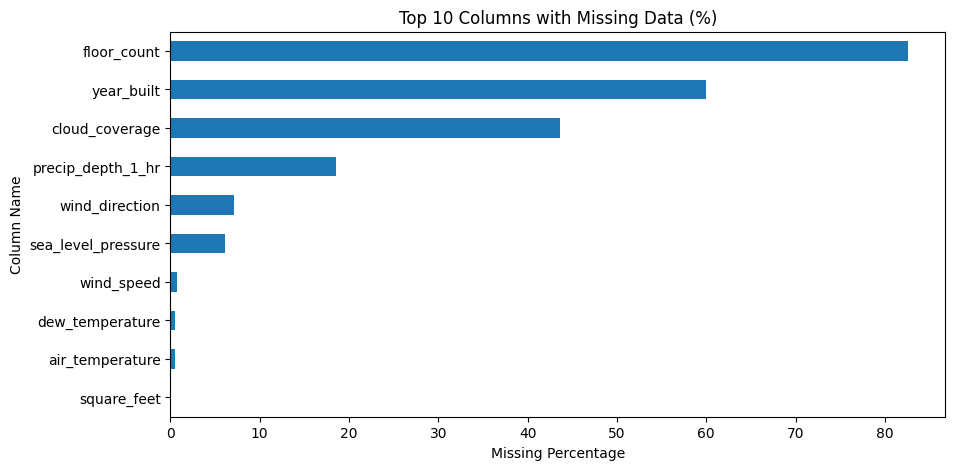

In [ ]:
# Check for missing values
def check_missing_values():
    missing_counts = df.isnull().sum() # Calculate missing counts
    missing_pct = (missing_counts / len(df)) * 100 # Calculate missing percentages

    missing_summary = pd.DataFrame({
        'Missing Count': missing_counts,
        'Missing %': missing_pct
    }).sort_values('Missing %', ascending=False)

    print(missing_summary.head(15))


    missing_pct.sort_values(ascending=False).head(10).sort_values().plot(kind='barh', figsize=(10,5))
    plt.title("Top 10 Columns with Missing Data (%)")
    plt.xlabel("Missing Percentage")
    plt.ylabel("Column Name")
    plt.show()

check_missing_values()

Missing here are mostly weather information with **floor_count** which has about `82.65%` and **year_built** `59.99%`.
We will think of either to drop this missing values based on the dependencies of the meter reading. Because it is impossible to postulate the values of this building.

For other case of missing values are the weather data which is **cloud_coverage** (43.66%) might be difficult to impute but will find impute strategy such as mean of this values grouped by `'site_id','day_of_month'`.
still on the weather data approach, we have other features which have `< 20%` missing data and can use the same impute strategy.


The data imputation strategy will mean of the `site_id`, `day` and `month`, so wee need to add the day and month information.
Each month comes in a season and temperature varies lots in a season.

```python

air_temperature_filler = pd.DataFrame(df.groupby(['site_id','day','month'])['air_temperature'].mean(),columns=["air_temperature"])

```


In [ ]:
# Add a new time-based feature for manipulation
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df["day"] = df["timestamp"].dt.day
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year

In [ ]:
# Fill missing values with
df['air_temperature'] = df.groupby(['site_id', 'day', 'month'])['air_temperature'].transform(lambda x: x.fillna(x.mean()))
df['dew_temperature'] = df.groupby(['site_id', 'day', 'month'])['dew_temperature'].transform(lambda x: x.fillna(x.mean()))
df['wind_speed'] = df.groupby(['site_id', 'day', 'month'])['wind_speed'].transform(lambda x: x.fillna(x.mean()))
df['sea_level_pressure'] = df.groupby(['site_id', 'day', 'month'])['sea_level_pressure'].transform(lambda x: x.fillna(x.mean()))
df['precip_depth_1_hr'] = df.groupby(['site_id', 'day', 'month'])['precip_depth_1_hr'].transform(lambda x: x.fillna(x.mean()))
df['cloud_coverage'] = df.groupby(['site_id', 'day', 'month'])['cloud_coverage'].transform(lambda x: x.fillna(x.mean()))

                    Missing Count  Missing %
floor_count              16709167  82.652772
year_built               12127645  59.990033
precip_depth_1_hr         2825816  13.978047
wind_direction            1449048   7.167792
cloud_coverage            1397901   6.914791
sea_level_pressure         833317   4.122046
site_id                         0   0.000000
timestamp                       0   0.000000
meter                           0   0.000000
building_id                     0   0.000000
meter_reading                   0   0.000000
primary_use                     0   0.000000
square_feet                     0   0.000000
dew_temperature                 0   0.000000
air_temperature                 0   0.000000


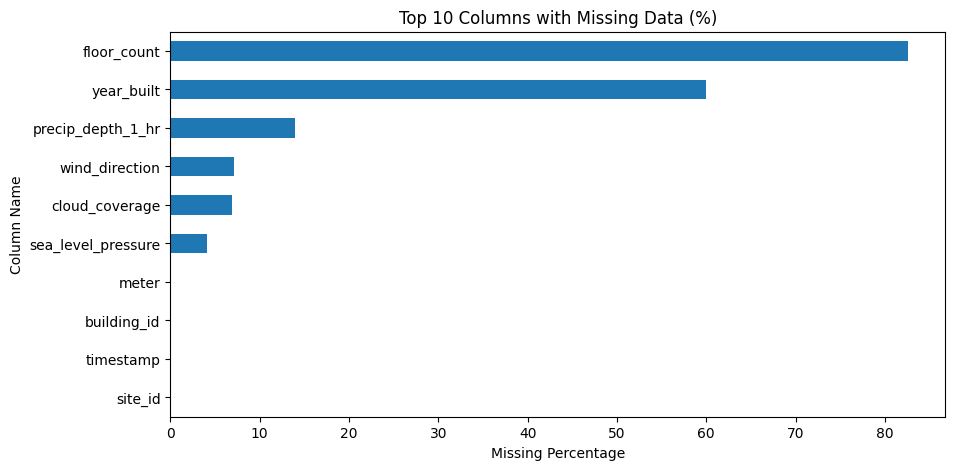

In [ ]:
check_missing_values()

There are still some missing weather value after this fix. We need to add another strategy. So, first, calculate mean weather value of day of the month and then fill rest missing values with last valid observation.

In [ ]:
def impute_missing_values_ffill(df, col):
    """
    Imputes missing values in target_col using forward-filled group means.
    Falls back to global median if NaNs remain.
    """
    group_cols = ['site_id', 'day', 'month']
    means_series = df.groupby(group_cols)[col].mean().ffill()
    mapped_values = df[group_cols].agg(tuple, axis=1).map(means_series)

    df[col] = df[col].fillna(mapped_values)

    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

impute_missing_values_ffill(df, 'cloud_coverage')
impute_missing_values_ffill(df, 'sea_level_pressure')
impute_missing_values_ffill(df, 'wind_direction')
impute_missing_values_ffill(df, 'precip_depth_1_hr')

## 2. Data Type Conversion

The timestamp column was converted from string format to datetime format to enable time-based feature extraction. New temporal variables including hour, day, dayofweek, month, and year were created from the timestamp column. The categorical feature primary_use was converted into numerical format using one-hot encoding so it can be used in machine learning models.

In [ ]:
# Add a new time-based feature for manipulation
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df["day"] = df["timestamp"].dt.day
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year

In [ ]:
# preview the data after manipulation.
df.head(5)

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,hour,dayofweek,day,month,year
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,NaN,25.0,...,20.0,-0.17395,1019.5,0.0,0.0,0,4,1,1,2016
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,NaN,25.0,...,20.0,-0.17395,1019.5,0.0,0.0,0,4,1,1,2016
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,NaN,25.0,...,20.0,-0.17395,1019.5,0.0,0.0,0,4,1,1,2016
3,3,0,2016-01-01,0.0,0,Education,23685,2002.0,NaN,25.0,...,20.0,-0.17395,1019.5,0.0,0.0,0,4,1,1,2016
4,4,0,2016-01-01,0.0,0,Education,116607,1975.0,NaN,25.0,...,20.0,-0.17395,1019.5,0.0,0.0,0,4,1,1,2016


In [ ]:
df.dtypes

,0
building_id,int16
meter,int8
timestamp,category
meter_reading,float32
site_id,int8
primary_use,category
square_feet,int32
year_built,float16
floor_count,float16
air_temperature,float16


## 3. Outlier Detection and Treatment

Method 1: IQR method

In [ ]:
numeric_cols = [
    'meter_reading', 'square_feet', 'year_built', 'floor_count',
    'air_temperature', 'cloud_coverage', 'dew_temperature',
    'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed'
]

iqr_outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    iqr_outlier_counts[col] = outliers

pd.DataFrame.from_dict(iqr_outlier_counts, orient='index', columns=['IQR_Outliers']).sort_values(by='IQR_Outliers', ascending=False)

,IQR_Outliers
precip_depth_1_hr,4983653
meter_reading,2473655
square_feet,1168305
sea_level_pressure,852766
wind_speed,555724
air_temperature,138778
floor_count,96574
dew_temperature,68833
year_built,0
cloud_coverage,0


Method 2: Z-score method

In [ ]:
from scipy.stats import zscore

zscore_outlier_counts = {}

for col in numeric_cols:
    z_scores = np.abs(zscore(df[col]))
    outliers = (z_scores > 3).sum()
    zscore_outlier_counts[col] = outliers

pd.DataFrame.from_dict(zscore_outlier_counts, orient='index', columns=['Zscore_Outliers']).sort_values(by='Zscore_Outliers', ascending=False)

,Zscore_Outliers
square_feet,445224
wind_speed,191356
meter_reading,3750
year_built,0
floor_count,0
cloud_coverage,0
air_temperature,0
dew_temperature,0
precip_depth_1_hr,0
sea_level_pressure,0


Method 3: Boxplots

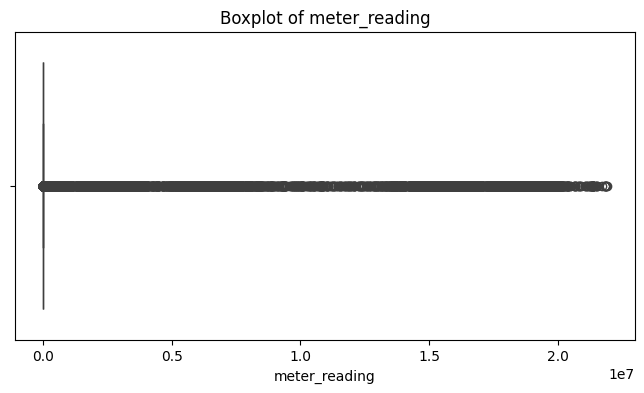

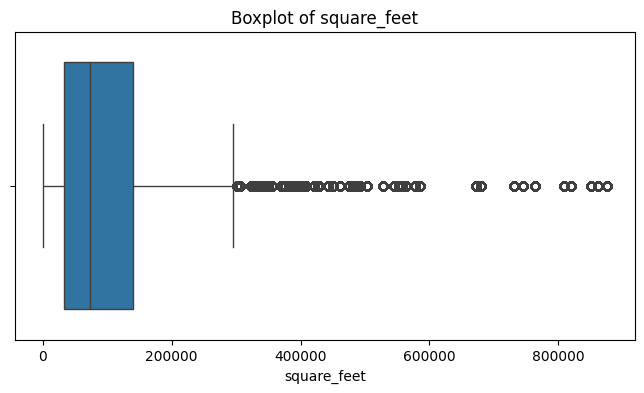

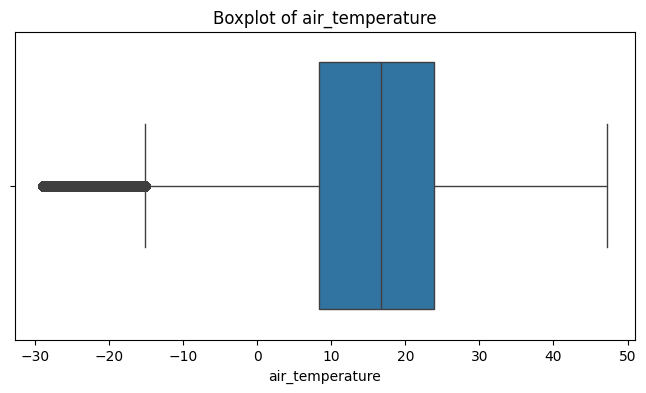

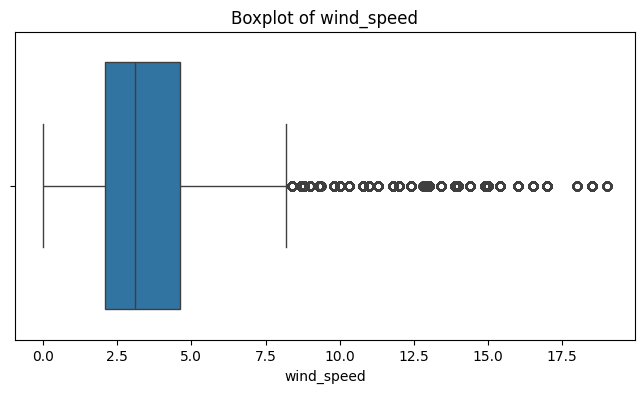

In [ ]:
for col in ['meter_reading', 'square_feet', 'air_temperature', 'wind_speed']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Treatment: Capping

In [ ]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

Outliers were detected using three methods: the IQR method, the Z-score method and bloxplots. Since this is a real-world electricity and weather dataset, extreme values may reflect actual building behavior rather than simple errors. Therefore, outliers were capped using the IQR bounds instead of removing rows, so the dataset size was preserved while reducing the influence of extreme values.

## 4. Feature Engineering

In [ ]:
# 1. Weekend feature
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Building age
df['building_age'] = df['year'] - df['year_built']

# 3. Temperature difference
df['temp_diff'] = df['air_temperature'] - df['dew_temperature']

# 4. Log transform for square feet
df['log_square_feet'] = np.log1p(df['square_feet'])

New features were created to improve model performance. The is_weekend feature was created to capture differences in electricity usage between weekdays and weekends. The building_age feature was created to represent how old a building is, which may influence energy consumption patterns. The temp_diff feature captures the difference between air temperature and dew temperature, which may help represent weather conditions more effectively. The log_square_feet feature was created to reduce skewness in building size and improve model learning

## 5. Data Normalization/Scaling

In [ ]:
from sklearn.preprocessing import RobustScaler

scale_cols = [
    'air_temperature', 'cloud_coverage', 'dew_temperature',
    'precip_depth_1_hr', 'sea_level_pressure',
    'wind_direction', 'wind_speed',
]

# Ensure all missing values are imputed in all columns that will be scaled
for col in scale_cols:
    # Replace any np.inf values with np.nan before imputation
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    impute_missing_values_ffill(df, col)

# Convert the columns to float32 to prevent potential overflow issues with float16
# when passed to RobustScaler, which might operate with float32 internally.
df[scale_cols] = df[scale_cols].astype(np.float32)

scaler = RobustScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

RobustScaler was used because the dataset contains outliers and variables with very different scales. This scaler is appropriate because it uses the median and interquartile range, making it less sensitive to extreme values than StandardScaler or MinMaxScaler.

## 6. Final Dataset Summary

In [ ]:
# come back to this later and use the merged data

before_summary = {
    'Rows': df_train.shape[0],
    'Columns': df_train.shape[1],
    'Missing Values': df_train.isnull().sum().sum()
}

after_summary = {
    'Rows': df.shape[0],
    'Columns': df.shape[1],
    'Missing Values': df.isnull().sum().sum()
}

summary_comparison = pd.DataFrame([before_summary, after_summary], index=['Before Wrangling', 'After Wrangling'])
summary_comparison

,Rows,Columns,Missing Values
Before Wrangling,20216100,4,0
After Wrangling,20216100,25,40964457


The final dataset after wrangling had corrected data types, imputed missing values, treated outliers, engineered new features, and scaled numerical variables. A comparison of the dataset before and after preprocessing shows that the data became complete and analysis-ready for machine learning.

In [ ]:
reduce_mem_usage(df)

Memory usage of dataframe is 1986.12 MB
Memory usage after optimization is: 848.62 MB
Decreased by 57.3%


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,wind_speed,hour,dayofweek,day,month,year,is_weekend,building_age,temp_diff,log_square_feet
0,0,0,2016-01-01 00:00:00,0.000000,0,Education,7432,2008.0,NaN,0.515137,...,-1.239258,0,4,1,1,2016,0,8.0,5.000000,8.914062
1,1,0,2016-01-01 00:00:00,0.000000,0,Education,2720,2004.0,NaN,0.515137,...,-1.239258,0,4,1,1,2016,0,12.0,5.000000,7.910156
2,2,0,2016-01-01 00:00:00,0.000000,0,Education,5376,1991.0,NaN,0.515137,...,-1.239258,0,4,1,1,2016,0,25.0,5.000000,8.593750
3,3,0,2016-01-01 00:00:00,0.000000,0,Education,23685,2002.0,NaN,0.515137,...,-1.239258,0,4,1,1,2016,0,14.0,5.000000,10.070312
4,4,0,2016-01-01 00:00:00,0.000000,0,Education,116607,1975.0,NaN,0.515137,...,-1.239258,0,4,1,1,2016,0,41.0,5.000000,11.664062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20216095,1444,0,2016-12-31 23:00:00,8.750000,15,Entertainment/public assembly,19619,1914.0,NaN,-0.931152,...,2.099609,23,5,31,12,2016,1,102.0,7.300781,9.882812
20216096,1445,0,2016-12-31 23:00:00,4.824219,15,Education,4298,NaN,NaN,-0.931152,...,2.099609,23,5,31,12,2016,1,NaN,7.300781,8.367188
20216097,1446,0,2016-12-31 23:00:00,0.000000,15,Entertainment/public assembly,11265,1997.0,NaN,-0.931152,...,2.099609,23,5,31,12,2016,1,19.0,7.300781,9.328125
20216098,1447,0,2016-12-31 23:00:00,159.625000,15,Lodging/residential,29775,2001.0,NaN,-0.931152,...,2.099609,23,5,31,12,2016,1,15.0,7.300781,10.304688


In [ ]:
del df_train

# PART C: Exploratory Data Analysis and Visualization

Required Visualizations (minimum):

* Distribution plots (histograms or KDE plots) for at least three key numerical features.
* A correlation heatmap showing relationships among numerical features, with interpretation of the strongest correlations.
* At least two categorical feature analyses using bar charts, count plots, or pie charts.
* A scatter plot or pair plot exploring relationships between features and/or between features and the target variable.
* A time series or trend visualization (if applicable to your dataset), or an alternative visualization type appropriate to your data (e.g., geographic plot, word cloud for text data).




### Detailed EDA

#### Target Variable (Meter Reading)

Looking at the target variable (**meter_reading**) in more detail.
Checks for this will include the distribution of the data to understand pattern.

In [ ]:
df[df['meter_reading'] < 0] # check for negative value in meter reading
# no value are negative

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,wind_speed,hour,dayofweek,day,month,year,is_weekend,building_age,temp_diff,log_square_feet


## Distribution Plots

In [ ]:
# Set seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

Skewness: nan


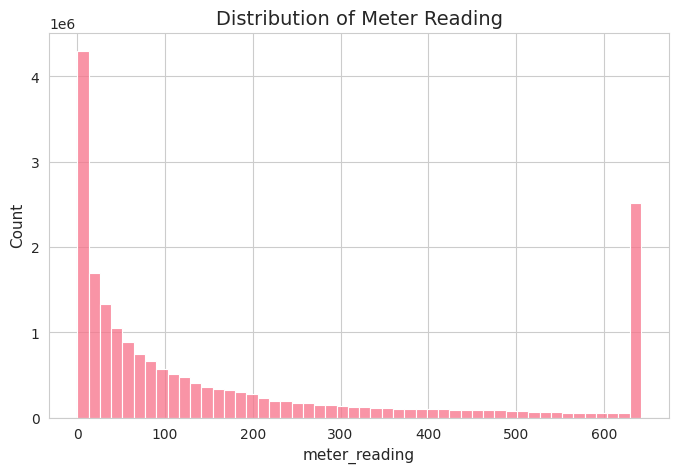

In [ ]:
print("Skewness:", df['meter_reading'].skew())

plt.figure(figsize=(8,5))
sns.histplot(df['meter_reading'], bins=50)
plt.title("Distribution of Meter Reading")
plt.show()

The result shows that the data is heavily skewed at the right because we have loads of data having a value of `zero` readings, which can often represent inactive meters or periods of no consumption. This heavy skewness can negatively impact the performance of many machine learning models, which often assume normally distributed ouput variables.



We will address this issue by applying a log transformation on the column using `np.log1p(df['meter_reading'])`.  This will reduce the level of data skewness

Skewness: nan


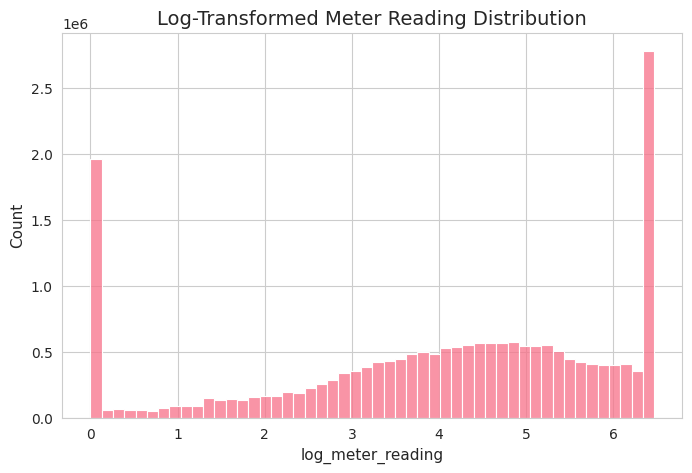

In [ ]:
df['log_meter_reading'] = np.log1p(df['meter_reading'])
print("Skewness:", df['log_meter_reading'].skew())
plt.figure(figsize=(8,5))
sns.histplot(df['log_meter_reading'], bins=50)
plt.title("Log-Transformed Meter Reading Distribution")
plt.show()

The result has a reasonable normal distribution after logging the value.

But Takeaway plans is removing zero's or not, to be sure that this values are not missing values but actually no consumption of electricity at the given hour.

Skewness: 1.0458473684703586


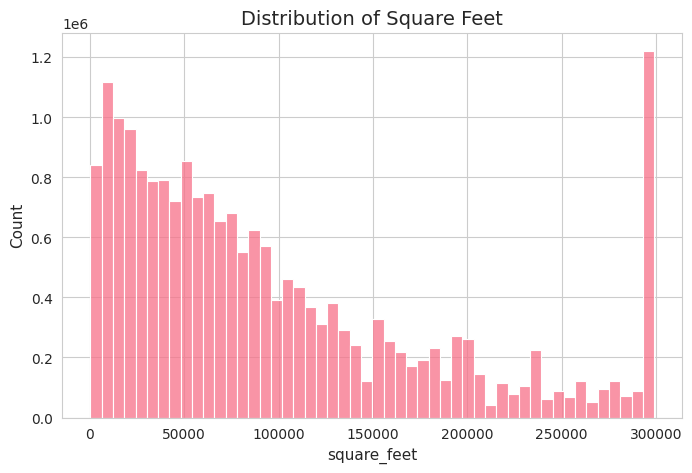

In [ ]:
print("Skewness:", df['square_feet'].skew())

plt.figure(figsize=(8,5))
sns.histplot(df['square_feet'], bins=50)
plt.title("Distribution of Square Feet")
plt.show()

Skewness: -0.9619984594618222


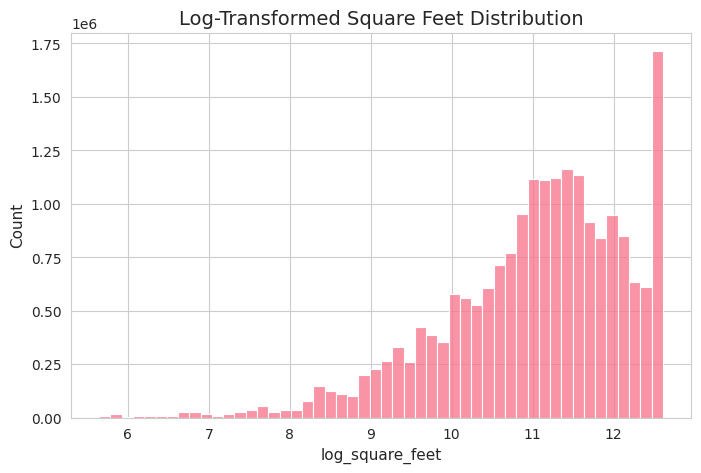

In [ ]:
df['log_square_feet'] = np.log(df['square_feet'])
print("Skewness:", df['log_square_feet'].skew())
plt.figure(figsize=(8,5))
sns.histplot(df['log_square_feet'], bins=50)
plt.title("Log-Transformed Square Feet Distribution")
plt.show()

Skewness: nan


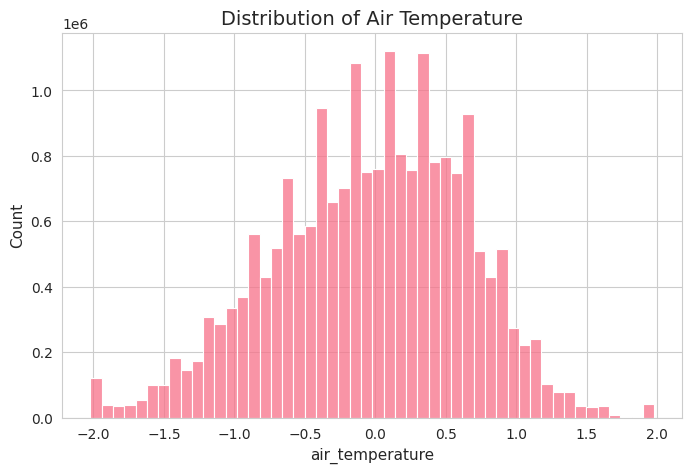

In [ ]:
print("Skewness:", df['air_temperature'].skew())

plt.figure(figsize=(8,5))
sns.histplot(df['air_temperature'], bins=50)
plt.title("Distribution of Air Temperature")
plt.show()

## Correlation Heat Map

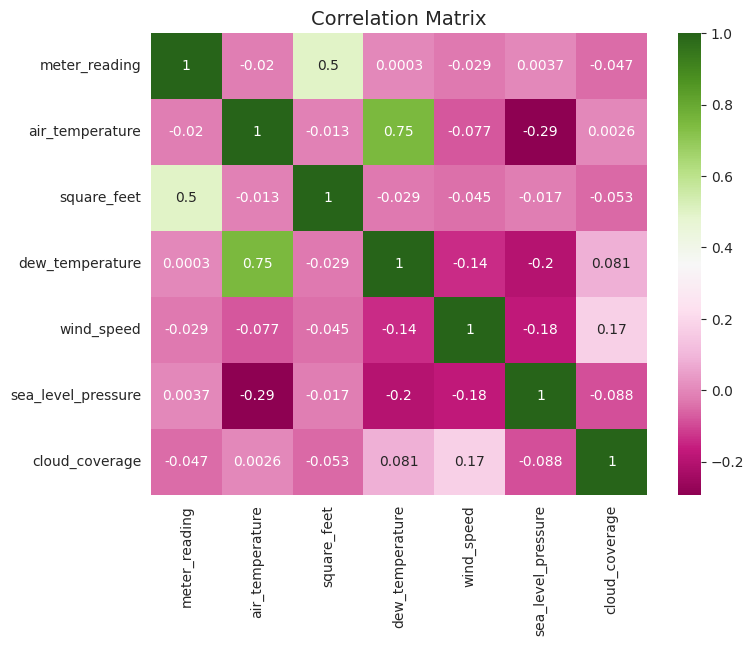

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
corr_matrix = df[['meter_reading','air_temperature','square_feet','dew_temperature',
                  'wind_speed','sea_level_pressure','cloud_coverage']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='PiYG')
plt.title("Correlation Matrix")
plt.show()


The heatmap reveals that **meter_reading** has only very weak linear correlations with the other numerical features in this aggregated view. This implies that predicting energy consumption will likely require more complex models that can capture non-linear relationships, interactions between features, or time-series dynamics, rather than relying on simple linear associations shown here. The strongest correlations are primarily between the weather variables themselves  **air_temperature** and **dew_temperature**\

## Categorical Feature

In [ ]:
# Set seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

def plot_numeric_data(df, numerical_cols = ['square_feet', 'year_built', 'floor_count'],
                      title='Building Data Distribution (Numeric)'):
    """
    Plot distributions for building meta dat, to be sure this data are in in the available and
    clean format
    """

    # Filter to only existing columns in the dataframe
    available_cols = [col for col in numerical_cols if col in df.columns]

    if not available_cols:
        print(" No specified numerical columns found in the dataframe.")
        return

    n_cols = len(available_cols)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5))

    # Handle single subplot case
    if n_cols == 1:
        axes = [axes]


    accent_color = sns.color_palette("husl")[0] # color accent for consistency

    for idx, col in enumerate(available_cols):
        ax = axes[idx]

        # Histogram with KDE
        sns.histplot(data=df, x=col, ax=ax, kde=True,
                     color=accent_color, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col} - Distribution', fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')

        ax.grid(axis='y', alpha=0.3)  # Add a subtle grid for readability

    fig.suptitle(title,
                 fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def plot_categorical_data(df):
    """
    Plot categorical distributions using bar plots and pie charts.
    """
    categorical_cols = ['primary_use', 'site_id']
    df[categorical_cols] = df[categorical_cols].astype('O')

    # Use a single color palette throughout
    base_palette = sns.color_palette("husl", n_colors=20)
    accent_color = base_palette[0]

    n_rows = len(categorical_cols)
    fig, axes = plt.subplots(n_rows, 2, figsize=(18, 5 * n_rows))

    # Handle single-row case for proper indexing
    if n_rows == 1:
        axes = np.array([[axes[0], axes[1]]])

    fig.suptitle('Building Data Distribution (Categorical)',
                 fontsize=20, fontweight='bold', y=1.02)

    for idx, col in enumerate(categorical_cols):
        value_counts = df[col].value_counts()

        # ===== LEFT: Bar Plot  =====
        top_20 = value_counts.iloc[:20]
        order = top_20.index

        sns.barplot(x=top_20.values, y=top_20.index.astype(str), ax=axes[idx, 0],
                    palette=[accent_color], edgecolor='black', alpha=0.85)
        axes[idx, 0].set_title(f'{col} - Category Frequency', fontweight='bold')
        axes[idx, 0].set_xlabel('Count')
        axes[idx, 0].set_ylabel(col)
        axes[idx, 0].grid(axis='x', alpha=0.3)

        # ===== RIGHT: Pie Chart =====
        top_10 = value_counts.head(10)

        # Handle edge case: if only 1 category exists
        if len(top_10) == 1:
            axes[idx, 1].pie(top_10.values, labels=top_10.index,
                            colors=[accent_color], startangle=90)
        else:
            # Generate consistent colors from single palette
            pie_colors = sns.light_palette(accent_color, n_colors=len(top_10), reverse=True)
            axes[idx, 1].pie(top_10.values, labels=top_10.index, autopct='%1.1f%%',
                            startangle=90, colors=pie_colors,
                            textprops={'fontsize': 9}, wedgeprops=dict(edgecolor='white'))

        axes[idx, 1].set_title(f'{col} - Top 10 Proportions', fontweight='bold')
        axes[idx, 1].axis('equal')  # Ensure pie is circular

    # Hide any unused subplots (if some columns were filtered out)
    for i in range(len(categorical_cols), n_rows):
        axes[i, 0].set_visible(False)
        axes[i, 1].set_visible(False)

    plt.tight_layout()
    plt.show()

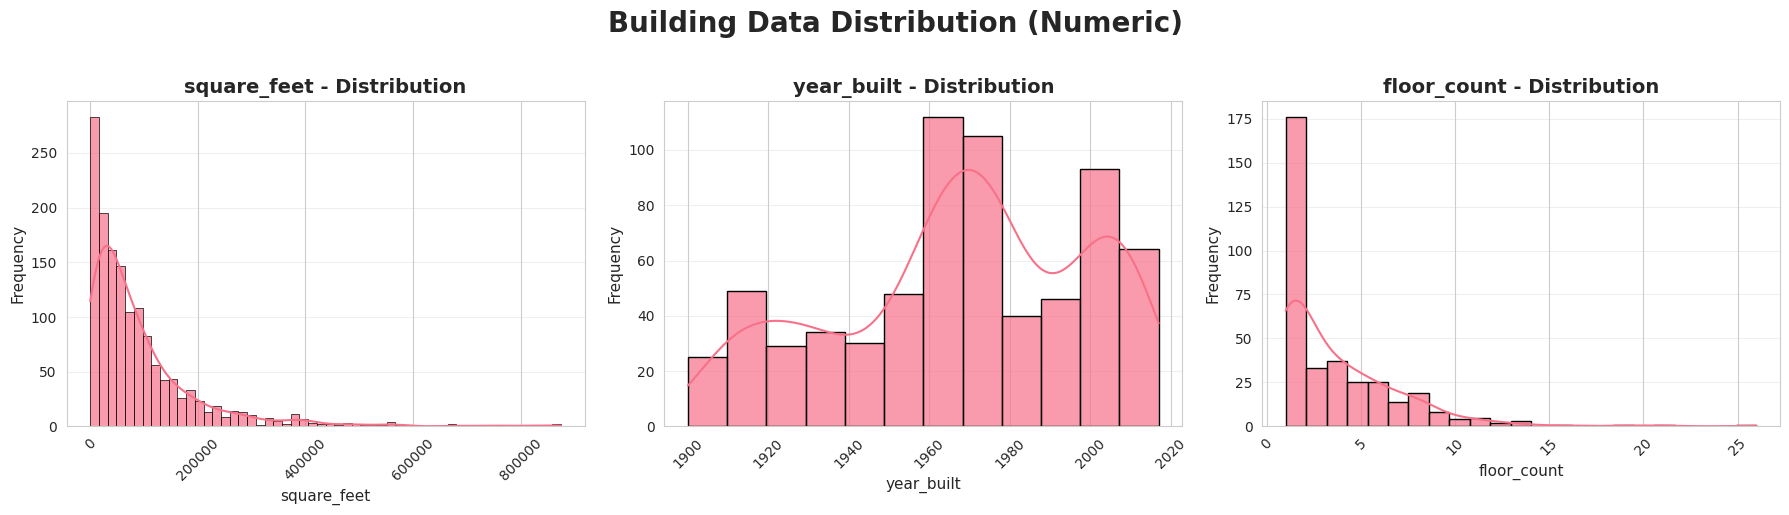

In [ ]:
# Plot the numeric data distribution of building data
plot_numeric_data(df_building_metadata)

From the graph above
1. `square_feet`: This plot shows that the majority of buildings have a smaller square footage, with the distribution being heavily skewed to the right. There are a few buildings with very large square footage, which appear as a long tail on the right side of the histogram.

2. `year_built`: This histogram illustrates the distribution of building construction years. It reveals periods of higher and lower construction activity. You can observe clusters of buildings built in certain eras (**1960** and **1980**), and it helps identify the age profile of the buildings in the dataset. *We also found some building after the year 2016, but the energy data was generated in 2016, so let us check details about this buildings*.

3. `floor_count`: This plot displays the distribution of the number of floors in the buildings. Given that floor_count has a high percentage of missing values (as seen earlier), this plot only represents the distribution of buildings for which floor_count information is available. It typically shows that most buildings have a lower number of floors, with fewer buildings having many floors.

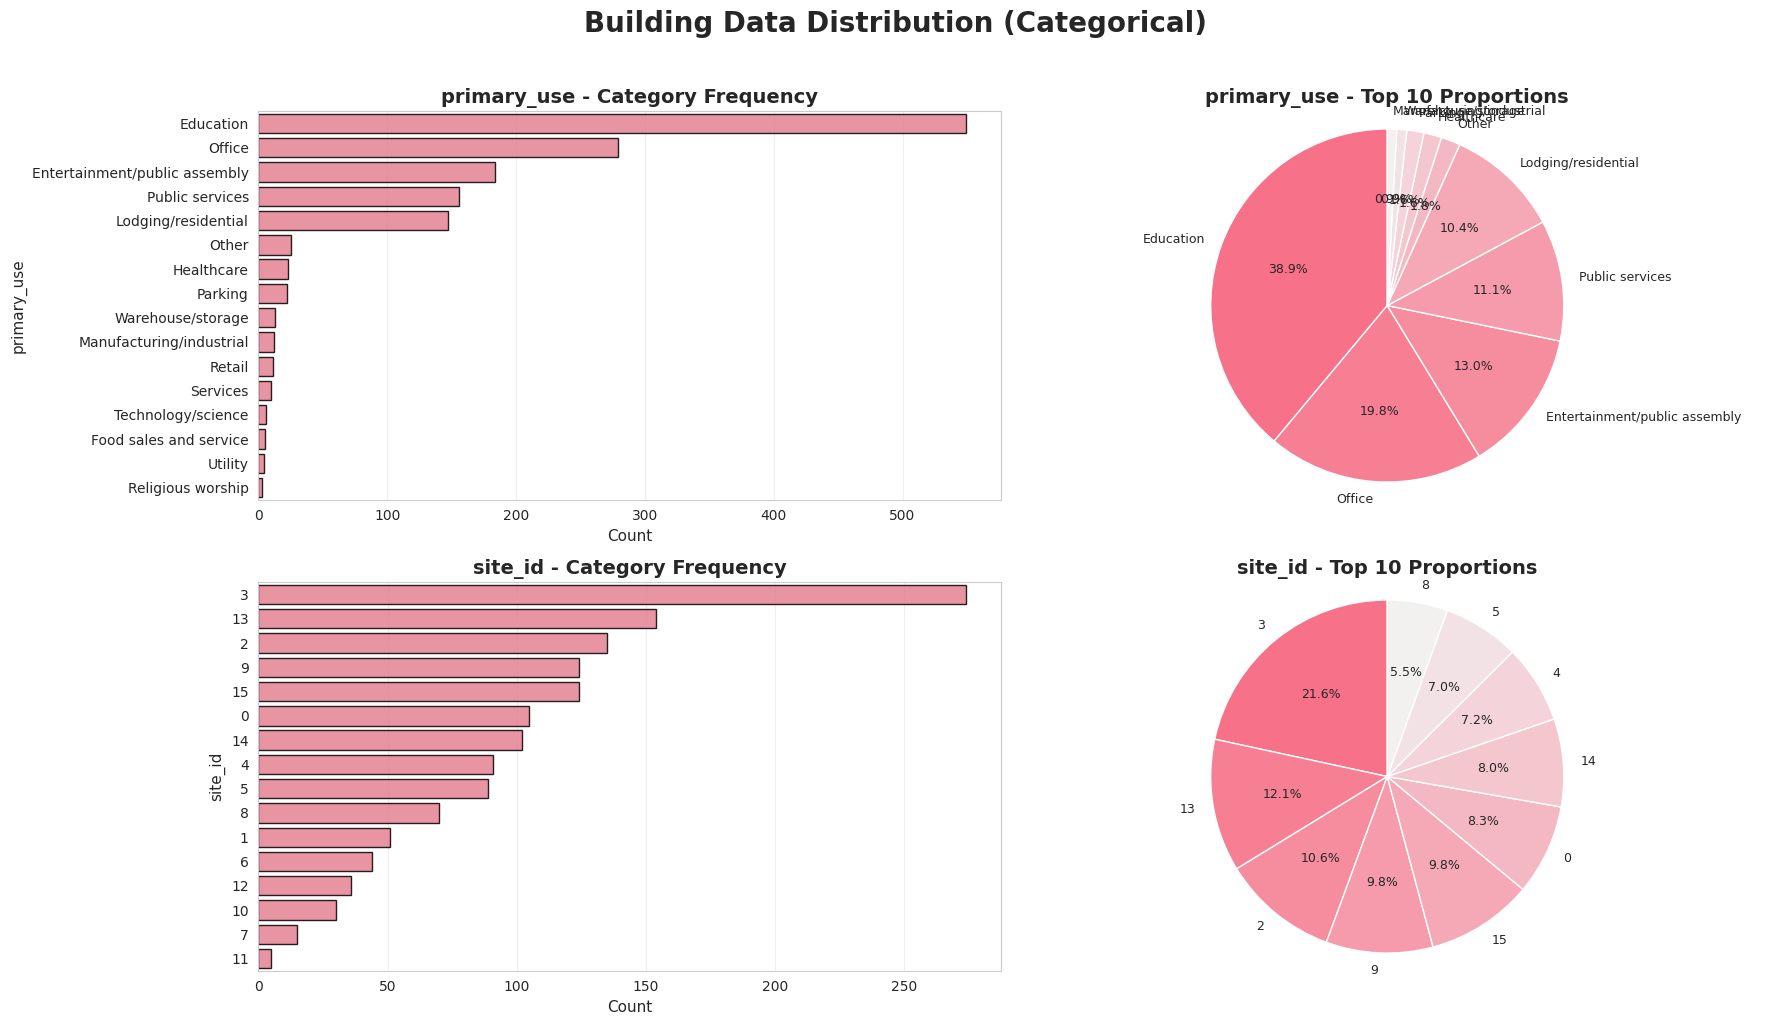

In [ ]:
# Plot the categorical data distribution of building data
plot_categorical_data(df_building_metadata)

## Scatter Plot

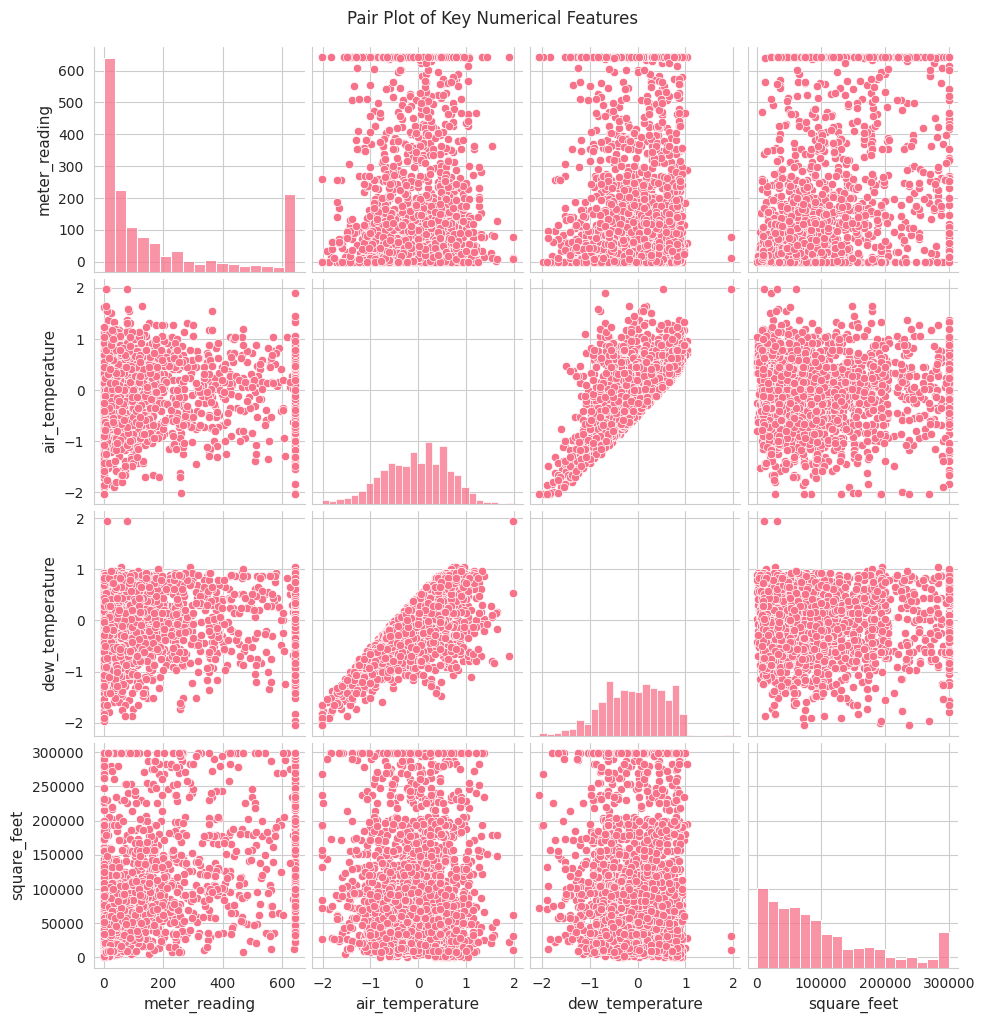

In [ ]:
pairplot_df = df[['meter_reading', 'air_temperature', 'dew_temperature', 'square_feet']].dropna().sample(2000, random_state=42)

sns.pairplot(pairplot_df)
plt.suptitle('Figure 7: Pair Plot of Key Numerical Features', y=1.02)
plt.show()

* `meter_reading` vs. `air_temperature` / `dew_temperature`: The scatter plots between meter_reading and both temperature variables (air_temperature, dew_temperature) show a broad spread of points. There isn't a strong linear correlation immediately visible, which is consistent with the very weak correlation coefficients you observed earlier. This suggests that while temperature might influence energy consumption, it's not a simple direct linear relationship across all buildings and times, and other factors are likely at play.

* `meter_reading` vs. `square_feet`: This plot shows a generally dispersed pattern. Although there's a slight tendency for larger buildings (higher square_feet) to have higher meter_reading values, the relationship is not very strong or clear-cut. This is also aligned with the weak positive correlation observed.

* `air_temperature` vs. `dew_temperature`: As expected, there's a strong positive linear relationship between air_temperature and dew_temperature. As air temperature increases, dew temperature also tends to increase. This high correlation suggests they often move together.

* `air_temperature` / `dew_temperature` vs. `square_feet`: These plots show no discernible pattern, which is expected as a building's physical size is generally independent of the ambient temperature or dew point.

## Time Series

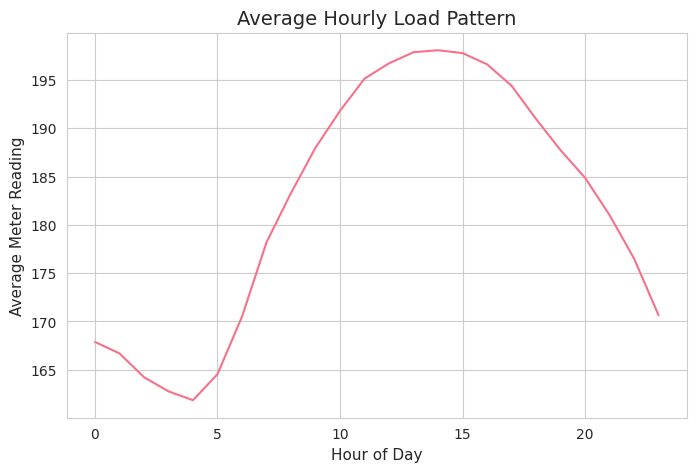

In [ ]:
hourly_avg = df.groupby('hour')['meter_reading'].mean()

plt.figure(figsize=(8,5))
hourly_avg.plot()
plt.title("Average Hourly Load Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Meter Reading")
plt.show()

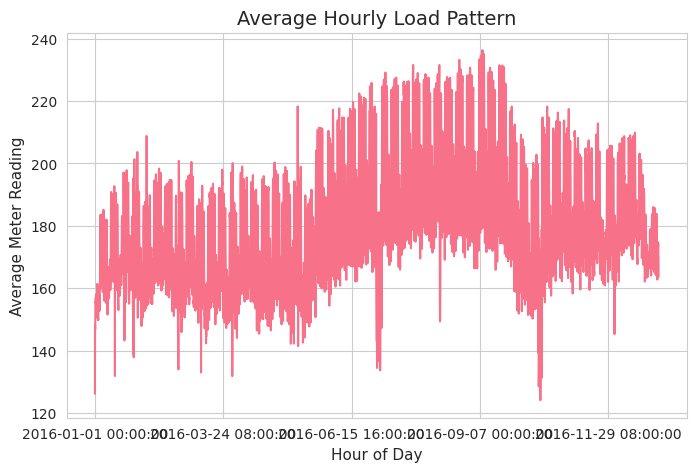

In [ ]:
hourly_yealy_load = df.groupby('timestamp')['meter_reading'].mean()

plt.figure(figsize=(8,5))
hourly_yealy_load.plot()
plt.title("Average Hourly Load Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Meter Reading")
plt.show()

We will see that that the building built in 2017 still has some valide energy usage.
This begs the question, was it errorneously inputed or something happened during the data collection process.

**Plan**
* Delete building in 2016/2017 because of the uncertainty of this data.

1. `primary_use`: These plots shows helps to quickly identify  **Education**, **Office**, **Entertainment/public assembly** are most common building in the dataset.

2. `site_id`: These chart displays the frequency of buildings across different site_ids, showing which sites have the most buildings registered. Since site_id represents different geographic locations or clusters, this helps understand the distribution of buildings across these locations. From the view it shouw site **3, 13**, with more than 30% coverage of the whole dataset.



##### Weather Related Data

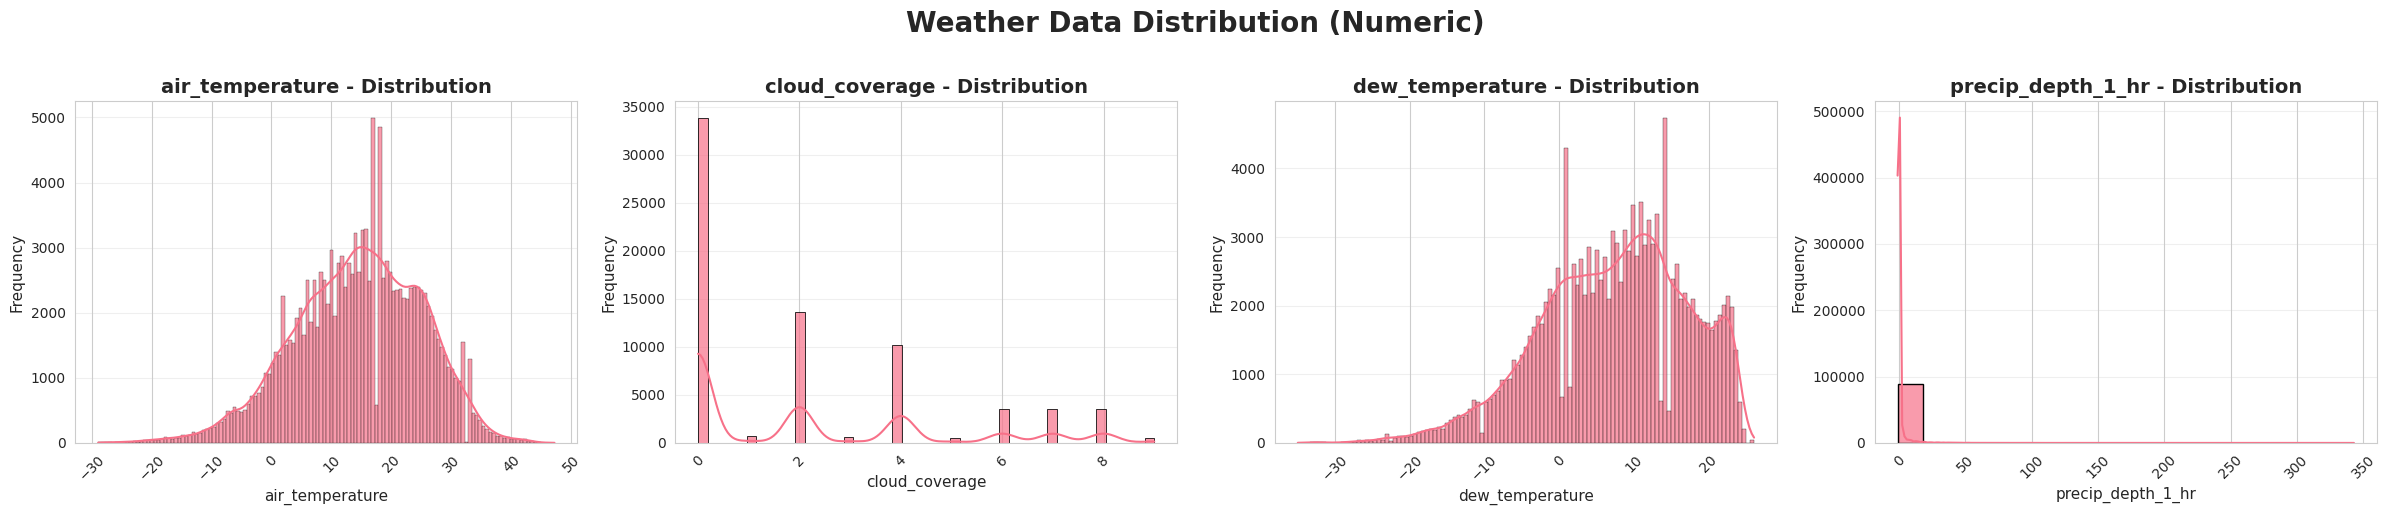

In [ ]:
# Plot 1
plot_numeric_data(df_weather, ['air_temperature','cloud_coverage', 'dew_temperature', 'precip_depth_1_hr'],
                  title = 'Weather Data Distribution (Numeric)')

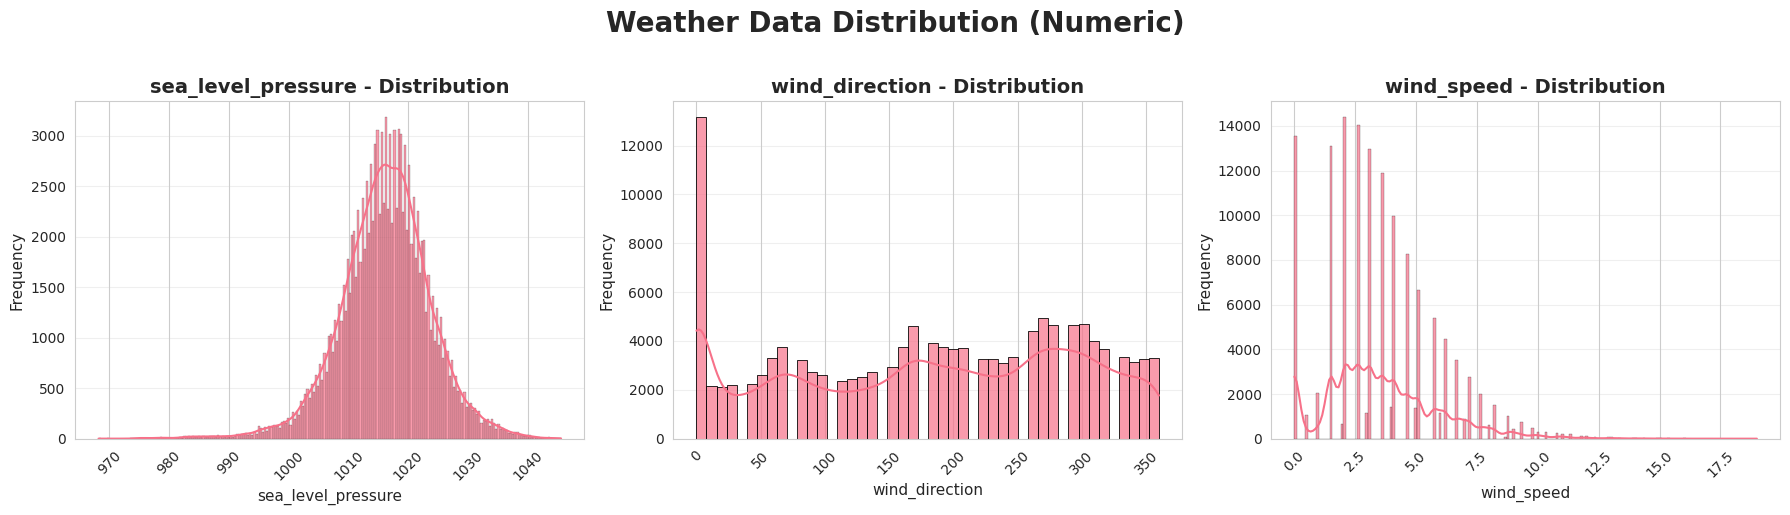

In [ ]:
# Plot 2
plot_numeric_data(df_weather, ['sea_level_pressure','wind_direction', 'wind_speed'], title = 'Weather Data Distribution (Numeric)')

From the graph, it can be seen that the there are no irregular data in the weather information. In addition, it should be noted that these values contains missing data with proposed plan to fix them in the sections discussed above.

#### Understanding Target Variable (Meter Reading) Relationship with Other Variable

##### Meter Reading and Time

Looking at reading at hourls we will see that readings are higher in the peak office hors withi the hour of `10 - 15` , which is expeceted for business and office usecase. However if you investigate further, you might observe some changes in this for  Home and other usecases.

Another observation is that the early hour of the morning `4-5` have low usage.



This looks weird, there are fluctuation in the building reading at different time.

* does this mean some buiding has missing reading or nearly no reading/
* Or is this the actual beahviour of energey reading and it changes with time.

Investigating this with count of energy or mean per building

In [ ]:
# Define the anomaly period
df['is_anomaly_period'] = df['timestamp'].dt.month.isin([7, 8, 9, 10])

# Compare average readings before/during/after anomaly
period_comparison = df.groupby('is_anomaly_period')['meter_reading'].agg(['mean', 'std', 'count'])
print(period_comparison)

# builidng before and after
building_before = df[df['timestamp'].dt.month.isin([1,2,3,4,5,6])].groupby('building_id')['meter_reading'].mean()
building_during = df[df['timestamp'].dt.month.isin([7,8,9,10])].groupby('building_id')['meter_reading'].mean()

# Combine into comparison dataframe
comparison = pd.DataFrame({
    'before_july': building_before,
    'july_to_oct': building_during
})

# Calculate % drop
comparison['pct_drop'] = (comparison['before_july'] - comparison['july_to_oct']) / comparison['before_july'] * 100

# Find buildings with >90% drop they might be the cause
suspects = comparison[comparison['pct_drop'] > 90].sort_values('pct_drop', ascending=False)
print("++" * 20)
print("Buildings with major (>90%) drops July-Oct:")
print(suspects.head(20))

                         mean         std     count
is_anomaly_period                                  
False              176.687607  217.565286  13314028
True               192.277451  222.683372   6902072
++++++++++++++++++++++++++++++++++++++++
Buildings with major (>90%) drops July-Oct:
             before_july  july_to_oct    pct_drop
building_id                                      
857             1.397171     0.000000  100.000000
815             0.280367     0.000000  100.000000
1192          335.311981     2.539454   99.242661
112            66.174065     1.052869   98.408936
1155          109.660591     6.210366   94.336739
345             1.407251     0.116721   91.705742


This indicates a substantial overall decrease in average meter readings during the defined anomaly period (**July - Oct**), suggesting a widespread issue or behavioral change.

The average meter reading drops significantly to about **510.18** showing a significan **80%** drop in the data.

In addtion, it has a table that identify buildings that experienced a dramatic drop (greater than 90%) in their average meter readings when comparing the first six months of the year (`before_july`) to the July-October period (`july_to_oct`).

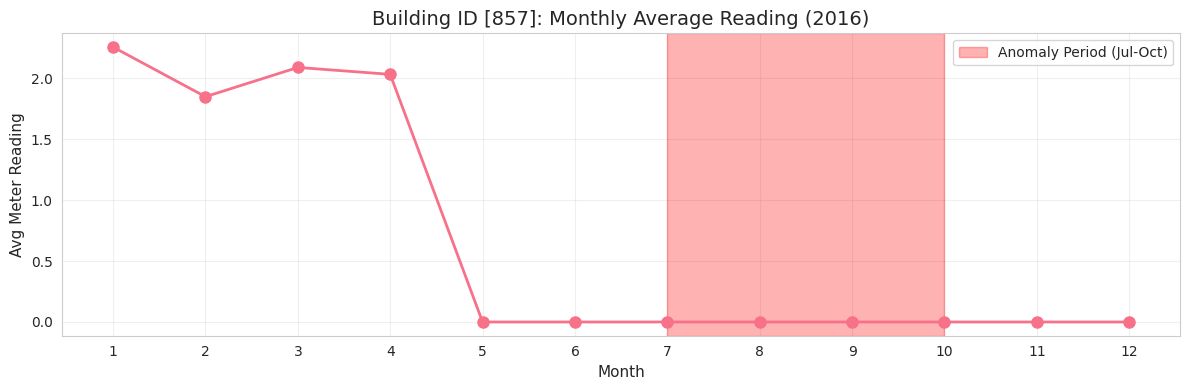

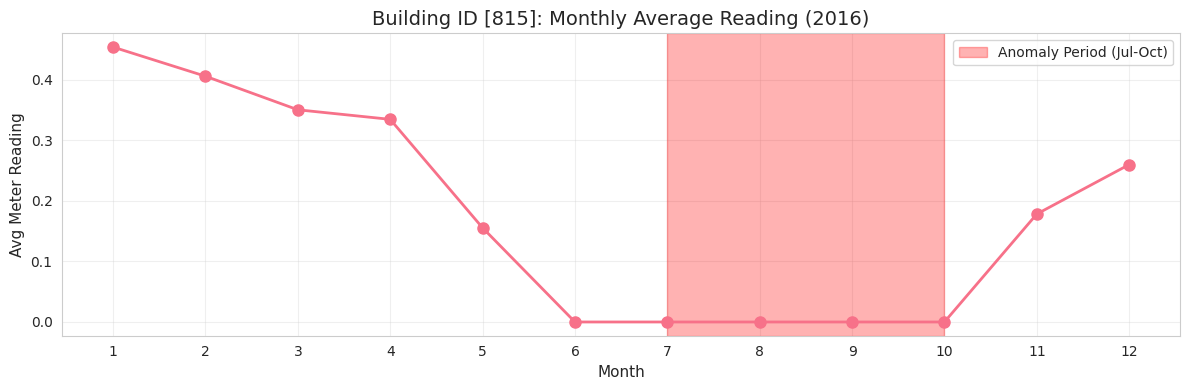

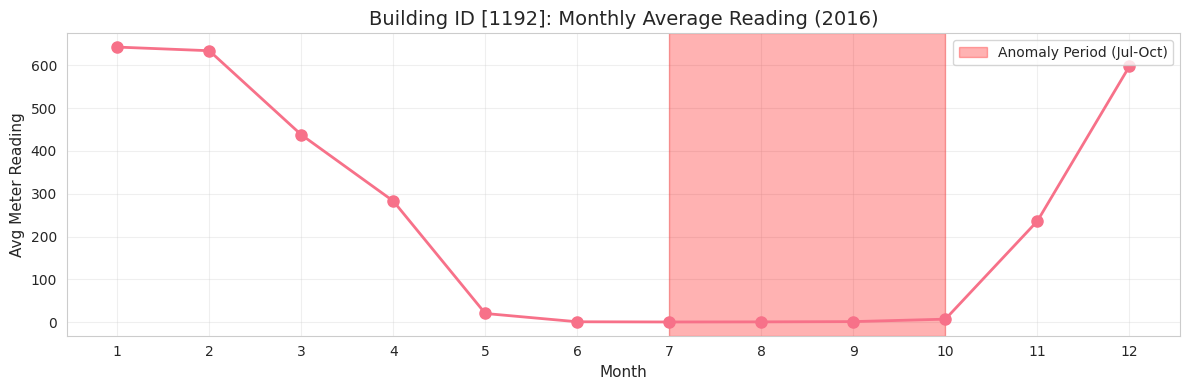

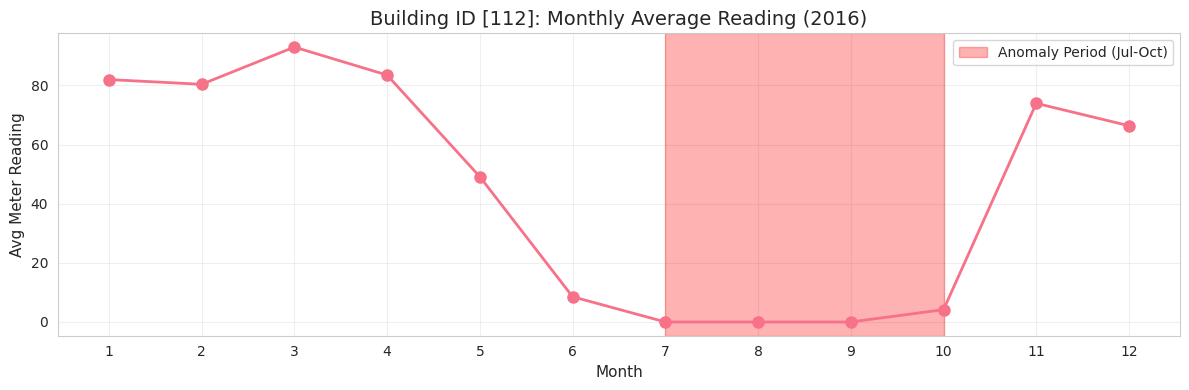

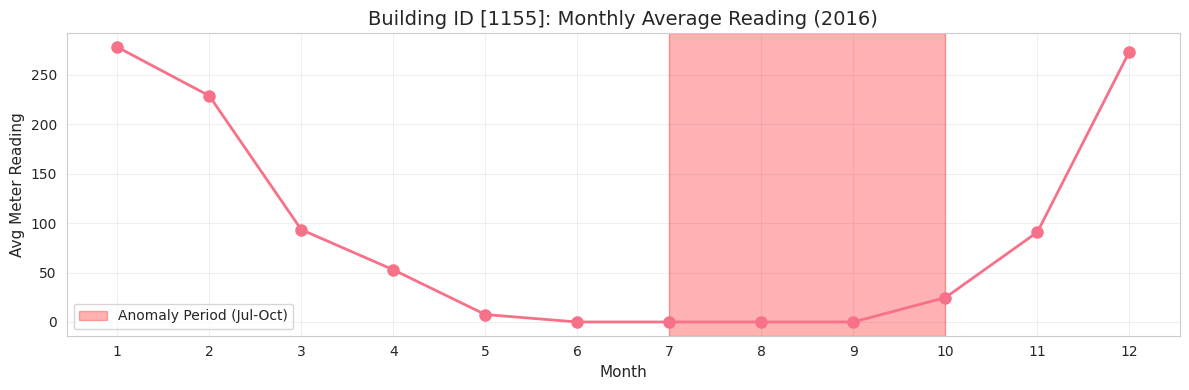

In [ ]:
def plot_building_timeline(building_id, df):
    building_data = df[df['building_id'] == building_id].copy()
    building_data['month'] = building_data['timestamp'].dt.month

    monthly_avg = building_data.groupby('month')['meter_reading'].mean()

    plt.figure(figsize=(12, 4))
    plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, markersize=8)
    plt.axvspan(7, 10, alpha=0.3, color='red', label='Anomaly Period (Jul-Oct)')
    plt.title(f'Building ID [{building_id}]: Monthly Average Reading (2016)')
    plt.xlabel('Month')
    plt.ylabel('Avg Meter Reading')
    plt.xticks(range(1, 13))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot top 5 suspects
for building_id in suspects.head(5).index:
    plot_building_timeline(building_id, df)

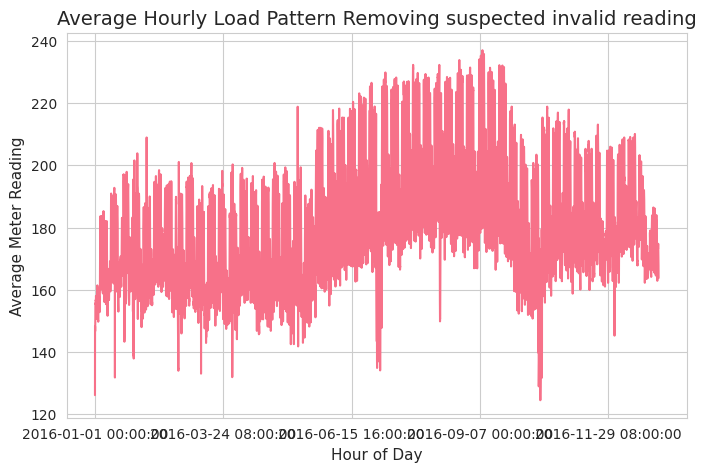

In [ ]:
hourly_yealy_load = df[~df['building_id'].isin(suspects.index.values)].groupby('timestamp')['meter_reading'].mean()

plt.figure(figsize=(8,5))
hourly_yealy_load.plot()
plt.title("Average Hourly Load Pattern Removing suspected invalid reading")
plt.xlabel("Hour of Day")
plt.ylabel("Average Meter Reading")
plt.show()

In [ ]:
suspect_count = df[~df['building_id'].isin(suspects.index.values)].shape[0]

In [ ]:
print(f"The data that will be removed will be {((df.shape[0] - suspect_count)/df.shape[0]) * 100:.2f}%")

The data that will be removed will be 0.30%


There are no pointers on where this issue is coming from. Suspect is that the builidng has been vacant/closed or meter broke/ a total power disconnection issu with that building during the period.

The solution we moved with is to drop information of these building.

After cleaning out those bad readings, the graph finally makes sense! We're now looking at a much more realistic range—everything falls between **400** and **1200**, which is way more believable than unusual spikes we saw before.

**Here's what stands out:**
The building has a pretty consistent baseline of around 400-500 that runs all year long—this is probably just the essentials like lighting, servers, and basic systems that never turn off.

**The seasonal pattern is pretty clear:**
* Winter months (Jan-Mar): Things are busier, hovering around 500-800. Makes sense—heating's running, people are inside.
* Spring through summer (Apr-Aug): It chills out to that 400-600 range. Probably fewer people around, milder weather, less HVAC demand.
* Then September and October hit: Boom—suddenly we're seeing 600-950 consistently. This is the highest sustained period all year. Something definitely changes here—maybe the building's fully occupied again (school year?), or they switched the HVAC to heating mode.
* November: Just as quickly, it drops right back down to that 400-500 baseline.
* December: Creeps back up to 600-750 as winter sets in again.

**The weird stuff:**
That massive spike in late October hitting 1200+ really stands out. It's so sharp and isolated that it's probably either a data glitch or some one-time event—like maybe they tested the fire alarm system, flushed the HVAC, or had some kind of emergency situation.

**Summary**: The Sep-Oct surge looks legit but needs investigating. That November spike? Probably an outlier we should double-check.

The 0.51% is small, and can be safely removed.

Look at the usage per week: Does weekday after the usage of energy?

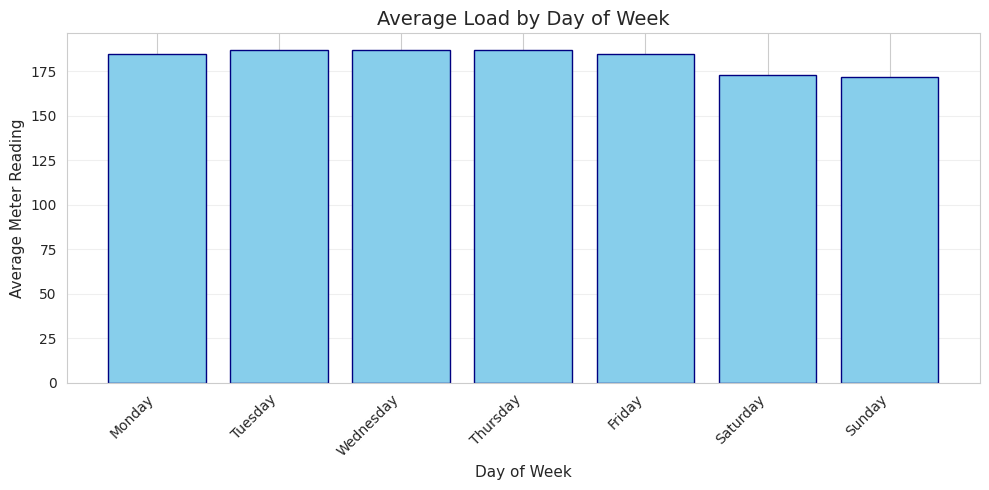

In [ ]:
df['day_name'] = df['timestamp'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_avg = df.groupby('day_name')['meter_reading'].mean()

# Reindex to ensure correct order (in case some days are missing)
weekly_avg = weekly_avg.reindex(day_order).dropna()

plt.figure(figsize=(10, 5))
plt.bar(weekly_avg.index, weekly_avg.values, color='skyblue', edgecolor='navy')
plt.title("Average Load by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Meter Reading")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The graph shows the following result and intepretation:
1. Peak Consumption on Mid-Weekdays with **Wednesday** showing the highest average meter reading. Tuesday and Thursday also show relatively high consumption.

2. Lower Consumption Towards Weekends   compared to the mid-week peaks.
Lowest Consumption happens on the weekend (**Saturday** and **Sunday**)exhibit the lowest average meter readings, indicating significantly reduced energy usage during non-working days. This pattern is common for many commercial or institutional buildings that operate primarily during weekdays.

##### Meter Reading and Meter

The meter id code from the documentaiton reads as

* 0: electricity
* 1: chilledwater
* 2: steam
* 3: hotwater

Not every building has all meter type. This meter are the readings and the usecase. Let us investigate into how this meter consumes energy.

In [ ]:
# Meter type mapping
meter_types = {0: 'Electricity', 1: 'Chilled Water', 2: 'Steam', 3: 'Hot Water'}


# ============================================================================
# SUMMARY STATISTICS TABLE
# ============================================================================
print("="*80)
print("METER TYPE ANALYSIS SUMMARY")
print("="*80)

summary_data = []
for meter_id, meter_name in meter_types.items():
    meter_data = df[df['meter'] == meter_id]
    if len(meter_data) > 0:
        summary_data.append({
            'Meter Type': meter_name,
            'Meter ID': meter_id,
            'Total Readings': len(meter_data),
            'Mean Reading': meter_data['meter_reading'].mean(),
            'Std Dev': meter_data['meter_reading'].std(),
            'Min': meter_data['meter_reading'].min(),
            'Max': meter_data['meter_reading'].max(),
            'Median': meter_data['meter_reading'].median()
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("="*80)


METER TYPE ANALYSIS SUMMARY
   Meter Type  Meter ID  Total Readings  Mean Reading  Std Dev  Min   Max    Median
  Electricity         0        12060910           NaN      0.0  0.0 642.5  62.84375
Chilled Water         1         4182440           NaN      0.0  0.0 642.5 120.50000
        Steam         2         2708713           NaN      0.0  0.0 642.5 257.75000
    Hot Water         3         1264037           NaN      0.0  0.0 642.5  39.62500


Let's check the memory usage of the variables in the current session.

This visual and analysis shows normal energy usage is actually quite low, but massive data errors maybe hiding some facts.
For every meter type, the typical reading is far lower than the average suggests because a few extreme outliers are skewing the numbers— for example, the **Steam** meter usually reads around **258**, but occasionally spikes to **21 million**, which is likely a sensor malfunction or recording error. **Electricity** is the most stable and reliable meter, while **Hot Water** frequently records zeros, suggesting periods of inactivity or meter failure.

In [ ]:
# 1. Investigate Steam outliers
steam_extreme = df[df['meter'] == 2]['meter_reading']
print(f"Steam readings > 10,000: {(steam_extreme > 10000).sum():,}")
print(f"Steam readings > 100,000: {(steam_extreme > 100000).sum():,}")
print(f"Steam readings > 1,000,000: {(steam_extreme > 1000000).sum():,}")
print(f"Steam readings > 10,000,000: {(steam_extreme > 10000000).sum():,}")

# 2. Check when these extremes occurred
extreme_steam = df[(df['meter'] == 2) & (df['meter_reading'] > 100000)].copy()
# Convert timestamp to datetime for min/max operations, as it was converted to category by reduce_mem_usage
extreme_steam['timestamp'] = pd.to_datetime(extreme_steam['timestamp'])

print(f"\nDate range of extreme Steam readings:")
print(f"First: {extreme_steam['timestamp'].min()}")
print(f"Last: {extreme_steam['timestamp'].max()}")
# print(f"Unique dates: {extreme_steam['timestamp'].dt.date.nunique()}")

# 3. Check if it's specific buildings
# all these are happening in site 13
if 'site_id' in extreme_steam.columns:
    print("\nSite distribution of extreme Steam readings:")
    print(extreme_steam['site_id'].value_counts())
else:
    print("\nError: 'site_id' column is not available in the dataframe.")    #extreme_steam['site_id'].value_counts()


Steam readings > 10,000: 0
Steam readings > 100,000: 0
Steam readings > 1,000,000: 0
Steam readings > 10,000,000: 0

Date range of extreme Steam readings:
First: NaT
Last: NaT

Site distribution of extreme Steam readings:
Series([], Name: count, dtype: int64)


In [ ]:
## Are ther specific use case of these extreme value.
extreme_steam['primary_use'].value_counts()

,count
primary_use,
Education,0
Entertainment/public assembly,0
Food sales and service,0
Healthcare,0
Lodging/residential,0
Manufacturing/industrial,0
Office,0
Other,0
Parking,0


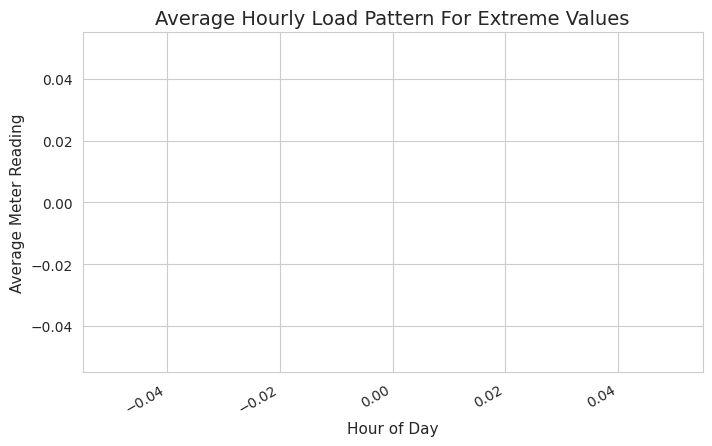

In [ ]:
## Are ther specific building this is happening and are they logged at a specific time
extreme_steam['timestamp'] = pd.to_datetime(extreme_steam['timestamp'])
hourly_yealy_load = extreme_steam.groupby('timestamp')['meter_reading'].mean()

plt.figure(figsize=(8,5))
hourly_yealy_load.plot()
plt.title("Average Hourly Load Pattern For Extreme Values")
plt.xlabel("Hour of Day")
plt.ylabel("Average Meter Reading")
plt.show()

In [ ]:
import os
import shutil

# Define the directory path without a trailing slash
dir_to_save = "/content/drive/MyDrive/DS & ML Research Team_Spring_26/Esther_ReviewPapers_Dataset/ashrae_data"

# Ensure clean slate: remove whatever is at dir_to_save if it exists
if os.path.exists(dir_to_save):
    if os.path.isdir(dir_to_save):
        shutil.rmtree(dir_to_save) # Remove directory and all its contents
    else: # It exists but is not a directory (e.g., file, symlink, etc.)
        os.remove(dir_to_save) # Remove the file-like object

# Now, create the directory safely
os.makedirs(dir_to_save, exist_ok=True)

# Define the full path for the output file
output_file_path = os.path.join(dir_to_save, "processed_data.csv.gz")

# Save the dataframe to the specified path
df.to_csv(output_file_path, compression='gzip')

FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/DS & ML Research Team_Spring_26/Esther_ReviewPapers_Dataset/ashrae_data'